✓ All libraries imported successfully!

LOADING DATASET FROM HUGGING FACE


Repo card metadata block was not found. Setting CardData to empty.



✓ Dataset loaded successfully!
  - Total records: 20,000
  - Total features: 17
  - Memory usage: 12.01 MB

INITIAL DATA EXPLORATION

First 5 rows:
     player_name role          league  market_value_m  age  minutes_played  goals_per90  assists_per90  shots_per90  progressive_passes_per90  pass_completion_pct  tackles_won_per90  interceptions_per90  aerial_duels_won_pct preferred_foot                      style_tags                                                bio
0  Jonas Schmidt   CB  Premier League            10.8   27            2609        0.034          0.013        0.127                     0.000                 91.3              1.590                0.386                  63.7           Left  [role-fit, athletic, tactical]  A role-appropriate player with clear strengths...
1  Jules Ribeiro   LB  Premier League             4.6   22            1066        0.019          0.168        1.980                     5.588                 83.6              1.288                0.840   

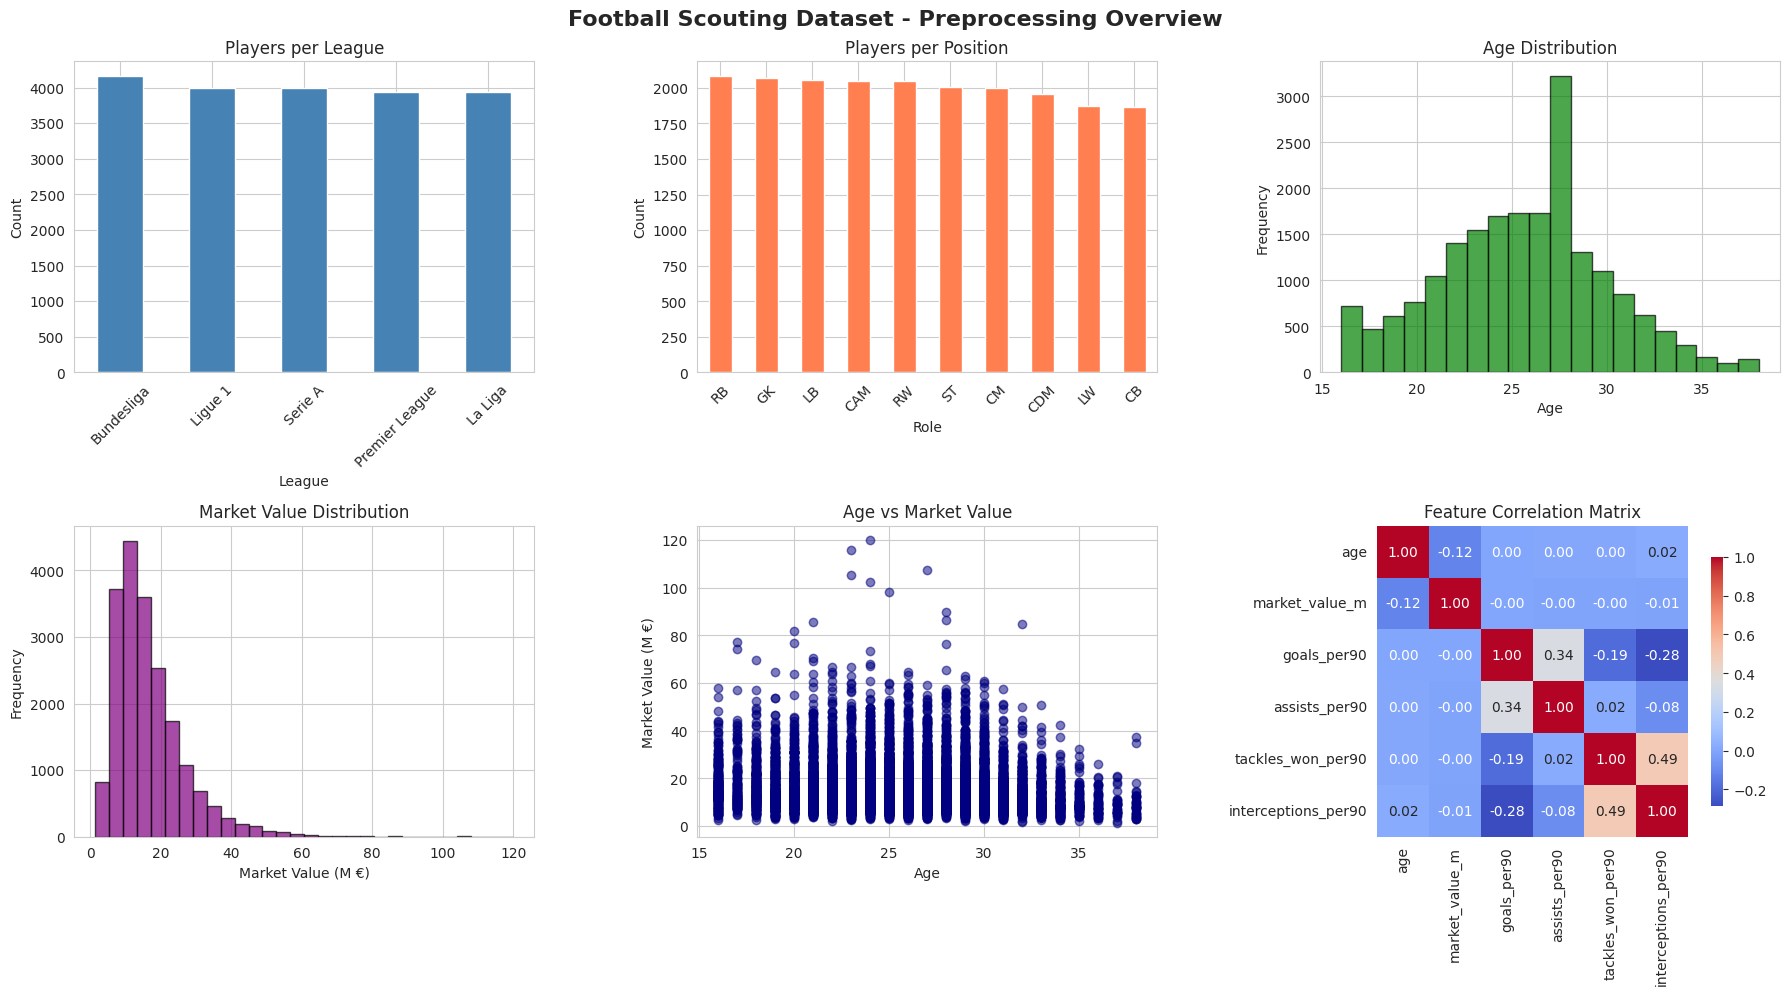


FINAL MESSAGE
Ἰ9 PREPROCESSING PIPELINE COMPLETED SUCCESSFULLY! Ἰ9


In [2]:
import pandas as pd
import numpy as np
from datasets import load_dataset
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
import warnings
import json
import ast

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 1000)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ All libraries imported successfully!")

print("\n" + "="*60)
print("LOADING DATASET FROM HUGGING FACE")
print("="*60)
dataset = load_dataset("talcabalo/big5-football-scouting")

df = dataset['train'].to_pandas()

print(f"\n✓ Dataset loaded successfully!")
print(f"  - Total records: {len(df):,}")
print(f"  - Total features: {len(df.columns)}")
print(f"  - Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print("\n" + "="*60)
print("INITIAL DATA EXPLORATION")
print("="*60)

print("\nFirst 5 rows:")
print(df.head())

print("\n\nColumn Information:")
print(df.dtypes)

print("\n\nNumerical Statistics:")
print(df.describe())

print("\n\nCategorical Column Summary:")
categorical_cols = ['league', 'role', 'preferred_foot']
for col in categorical_cols:
    if col in df.columns:
        print(f"  - {col}: {df[col].nunique()} unique values \u2192 {df[col].unique()[:5]}")

print("\n" + "="*60)
print("DATA QUALITY ASSESSMENT")
print("="*60)

missing_values = df.isnull().sum()
missing_percentage = (missing_values / len(df)) * 100

missing_df = pd.DataFrame({
    'Column': missing_values.index,
    'Missing Count': missing_values.values,
    'Missing Percentage': missing_percentage.values
})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)

if len(missing_df) > 0:
    print("\n\u26A0 Missing Values Found:")
    print(missing_df.to_string(index=False))
else:
    print("\n\u2713 No missing values found!")

duplicate_names = df[df.duplicated(subset=['player_name'], keep=False)]
print(f"\n\u2713 Duplicate player names: {len(duplicate_names)}")

# Ensure all object columns are hashable (e.g., strings) before checking for complete duplicates.
# This prevents errors if any 'object' column inadvertently contains unhashable types like lists or numpy arrays.
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].astype(str)

# Check for duplicate rows (complete duplicates)
duplicate_rows = df[df.duplicated(keep=False)]
print(f"\u2713 Complete duplicate rows: {len(duplicate_rows)}")

print("\n" + "="*60)
print("HANDLING MISSING VALUES")
print("="*60)

df_clean = df.copy()

numerical_cols = ['goals_per90', 'assists_per90', 'shots_per90',
                  'progressive_passes_per90', 'tackles_won_per90',
                  'interceptions_per90', 'pass_completion_pct',
                  'aerial_duels_won_pct']

for col in numerical_cols:
    if col in df_clean.columns and df_clean[col].isnull().any():
        df_clean[col] = df_clean.groupby('role')[col].transform(
            lambda x: x.fillna(x.median())
        )
        print(f"  - Filled {col} with role-specific medians")

if 'preferred_foot' in df_clean.columns and df_clean['preferred_foot'].isnull().any():
    mode_value = df_clean['preferred_foot'].mode()[0]
    df_clean['preferred_foot'].fillna(mode_value, inplace=True)
    print(f"  - Filled preferred_foot with mode: {mode_value}")

text_cols = ['style_tags', 'bio']
for col in text_cols:
    if col in df_clean.columns and df_clean[col].isnull().any():
        df_clean[col].fillna('Not available', inplace=True)
        print(f"  - Filled {col} with 'Not available'")

print(f"\n\u2713 Missing value handling complete!")
print(f"  - Remaining missing values: {df_clean.isnull().sum().sum()}")

print("\n" + "="*60)
print("DATA TYPE CONVERSIONS")
print("="*60)

if 'age' in df_clean.columns:
    df_clean['age'] = df_clean['age'].astype(int)
    print("  - Converted age to integer")

if 'minutes_played' in df_clean.columns:
    df_clean['minutes_played'] = df_clean['minutes_played'].astype(int)
    print("  - Converted minutes_played to integer")

if 'market_value_m' in df_clean.columns:
    df_clean['market_value_m'] = df_clean['market_value_m'].astype(float)
    print("  - Ensured market_value_m is float")

for col in ['league', 'role', 'preferred_foot']:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].astype('category')
        print(f"  - Converted {col} to category type")

print(f"\n\u2713 Data type conversions complete!")

print("\n" + "="*60)
print("FEATURE ENGINEERING")
print("="*60)

df_clean['age_group'] = pd.cut(df_clean['age'],
                                bins=[0, 20, 25, 30, 35, 100],
                                labels=['Young (16-20)', 'Peak Early (21-25)',
                                       'Peak (26-30)', 'Experienced (31-35)',
                                       'Veteran (36+)'])
print("  - Created age_group feature")

df_clean['value_category'] = pd.cut(df_clean['market_value_m'],
                                     bins=[0, 10, 30, 60, 150],
                                     labels=['Low (<10M)', 'Medium (10-30M)',
                                            'High (30-60M)', 'Elite (>60M)'])
print("  - Created value_category feature")

df_clean['attacking_contribution'] = (df_clean['goals_per90'] +
                                      df_clean['assists_per90'])
print("  - Created attacking_contribution feature")

df_clean['defensive_contribution'] = (df_clean['tackles_won_per90'] +
                                      df_clean['interceptions_per90'])
print("  - Created defensive_contribution feature")

df_clean['playing_time_status'] = pd.cut(df_clean['minutes_played'],
                                         bins=[0, 900, 1800, 2700, 5000],
                                         labels=['Rarely Used (<900)',
                                                'Rotation (900-1800)',
                                                'Regular (1800-2700)',
                                                'Key Player (>2700)'])
print("  - Created playing_time_status feature")

df_clean['value_per_goal'] = df_clean['market_value_m'] / (df_clean['goals_per90'] + 0.01)
df_clean['value_per_assist'] = df_clean['market_value_m'] / (df_clean['assists_per90'] + 0.01)
print("  - Created value-for-money metrics")

position_mapping = {
    'GK': 'Goalkeeper',
    'CB': 'Defender',
    'LB': 'Defender',
    'RB': 'Defender',
    'CDM': 'Midfielder',
    'CM': 'Midfielder',
    'CAM': 'Midfielder',
    'LW': 'Attacker',
    'RW': 'Attacker',
    'ST': 'Attacker'
}
df_clean['position_category'] = df_clean['role'].map(position_mapping)
print("  - Created position_category feature")

df_clean['experience_score'] = (df_clean['age'] * 0.3 +
                                df_clean['minutes_played'] / 100)
print("  - Created experience_score feature")

if 'style_tags' in df_clean.columns:
    df_clean['num_style_tags'] = df_clean['style_tags'].apply(
        lambda x: len(eval(x)) if isinstance(x, str) and x.startswith('[') else 0
    )
    print("  - Created num_style_tags feature")

print(f"\n\u2713 Feature engineering complete! Added {len(df_clean.columns) - len(df.columns)} new features")

print("\n" + "="*60)
print("OUTLIER DETECTION AND HANDLING")
print("="*60)

def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

outlier_cols = ['market_value_m', 'goals_per90', 'assists_per90']
outlier_summary = {}

for col in outlier_cols:
    if col in df_clean.columns:
        outliers, lower, upper = detect_outliers_iqr(df_clean, col)
        outlier_summary[col] = {
            'count': len(outliers),
            'percentage': (len(outliers) / len(df_clean)) * 100,
            'bounds': (lower, upper)
        }
        print(f"  - {col}: {len(outliers)} outliers ({outlier_summary[col]['percentage']:.2f}%)")

print("\n\u2713 Outliers detected but retained (represent elite players)")

print("\n" + "="*60)
print("ENCODING CATEGORICAL VARIABLES")
print("="*60)

df_encoded = df_clean.copy()

label_encoders = {}

categorical_to_encode = ['league', 'preferred_foot', 'role']

for col in categorical_to_encode:
    if col in df_encoded.columns:
        dummies = pd.get_dummies(df_encoded[col], prefix=col, drop_first=False)
        df_encoded = pd.concat([df_encoded, dummies], axis=1)
        print(f"  - One-hot encoded {col} \u2192 {len(dummies.columns)} new columns")

df_encoded['league_original'] = df_clean['league']
df_encoded['role_original'] = df_clean['role']
df_encoded['preferred_foot_original'] = df_clean['preferred_foot']

print(f"\n\u2713 Encoding complete! Total columns: {len(df_encoded.columns)}")

print("\n" + "="*60)
print("FEATURE SCALING & NORMALIZATION")
print("="*60)

df_scaled = df_encoded.copy()

features_to_scale = [
    'age', 'minutes_played', 'market_value_m',
    'goals_per90', 'assists_per90', 'shots_per90',
    'progressive_passes_per90', 'tackles_won_per90', 'interceptions_per90',
    'pass_completion_pct', 'aerial_duels_won_pct',
    'attacking_contribution', 'defensive_contribution'
]

features_to_scale = [col for col in features_to_scale if col in df_scaled.columns]

scaler_standard = StandardScaler()
df_scaled[[f'{col}_scaled' for col in features_to_scale]] = scaler_standard.fit_transform(
    df_scaled[features_to_scale]
)
print(f"  - Applied StandardScaler to {len(features_to_scale)} features")

scaler_minmax = MinMaxScaler()
df_scaled[[f'{col}_normalized' for col in features_to_scale]] = scaler_minmax.fit_transform(
    df_scaled[features_to_scale]
)
print(f"  - Applied MinMaxScaler to {len(features_to_scale)} features")

print(f"\n\u2713 Scaling complete!")

print("\n" + "="*60)
print("DATA VALIDATION")
print("="*60)

validations = {
    'age': (16, 38),
    'market_value_m': (1, 120),
    'pass_completion_pct': (0, 100),
    'aerial_duels_won_pct': (0, 100)
}

validation_issues = []
for col, (min_val, max_val) in validations.items():
    if col in df_clean.columns:
        out_of_range = df_clean[(df_clean[col] < min_val) | (df_clean[col] > max_val)]
        if len(out_of_range) > 0:
            validation_issues.append(f"{col}: {len(out_of_range)} values out of range")
        else:
            print(f"  \u2713 {col}: All values within expected range [{min_val}, {max_val}]")

if validation_issues:
    print("\n\u26A0 Validation issues found:")
    for issue in validation_issues:
        print(f"  - {issue}")
else:
    print("\n\u2713 All validations passed!")

print("\n  Logical Consistency Checks:")
gk_goals = df_clean[df_clean['role'] == 'GK']['goals_per90'].mean()
print(f"  - Avg goals for GK: {gk_goals:.4f} (should be ~0)")

st_shots = df_clean[df_clean['role'] == 'ST']['shots_per90'].mean()
print(f"  - Avg shots for ST: {st_shots:.2f} (should be >2)")

print("\n" + "="*60)
print("CREATING FEATURE SUBSETS")
print("="*60)

performance_features = [
    'goals_per90', 'assists_per90', 'shots_per90',
    'progressive_passes_per90', 'tackles_won_per90', 'interceptions_per90',
    'pass_completion_pct', 'aerial_duels_won_pct',
    'attacking_contribution', 'defensive_contribution'
]
df_performance = df_clean[['player_name', 'role'] + performance_features].copy()
print(f"  - Created performance feature subset: {len(performance_features)} features")

profile_features = [
    'age', 'role', 'preferred_foot', 'minutes_played',
    'market_value_m', 'goals_per90', 'assists_per90'
]
df_profile = df_clean[['player_name'] + profile_features].copy()
print(f"  - Created player profile subset: {len(profile_features)} features")

scout_features = [
    'player_name', 'age', 'league', 'role', 'market_value_m',
    'age_group', 'value_category', 'playing_time_status',
    'attacking_contribution', 'defensive_contribution', 'bio'
]
df_scout = df_clean[scout_features].copy()
print(f"  - Created scout report subset: {len(scout_features)} features")

budget_features = [
    'player_name', 'role', 'age', 'market_value_m',
    'goals_per90', 'assists_per90', 'value_per_goal', 'value_per_assist'
]
df_budget = df_clean[budget_features].copy()
print(f"  - Created budget analysis subset: {len(budget_features)} features")

print("\n" + "="*60)
print("TRAIN-TEST SPLIT")
print("="*60)

X = df_scaled[[col for col in df_scaled.columns if col.endswith('_scaled')]]
y = df_scaled['market_value_m']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=df_scaled['role_original']
)

print(f"  - Training set: {len(X_train)} samples ({len(X_train)/len(df_scaled)*100:.1f}%)")
print(f"  - Test set: {len(X_test)} samples ({len(X_test)/len(df_scaled)*100:.1f}%)")
print(f"  - Number of features: {X_train.shape[1]}")

train_indices = X_train.index
test_indices = X_test.index

print("\n" + "="*60)
print("EXPORTING PREPROCESSED DATA")
print("="*60)

df_clean.to_csv('football_data_cleaned.csv', index=False)
print("  \u2713 Saved: football_data_cleaned.csv")

df_encoded.to_csv('football_data_encoded.csv', index=False)
print("  \u2713 Saved: football_data_encoded.csv")

df_scaled.to_csv('football_data_scaled.csv', index=False)
print("  \u2713 Saved: football_data_scaled.csv")

df_performance.to_csv('football_performance_features.csv', index=False)
print("  \u2713 Saved: football_performance_features.csv")

df_profile.to_csv('football_player_profiles.csv', index=False)
print("  \u2713 Saved: football_player_profiles.csv")

df_scout.to_csv('football_scout_reports.csv', index=False)
print("  \u2713 Saved: football_scout_reports.csv")

df_budget.to_csv('football_budget_analysis.csv', index=False)
print("  \u2713 Saved: football_budget_analysis.csv")

X_train.to_csv('X_train.csv', index=True)
X_test.to_csv('X_test.csv', index=True)
y_train.to_csv('y_train.csv', index=True)
y_test.to_csv('y_test.csv', index=True)
print("  \u2713 Saved: Train-test split files")

import pickle

with open('scaler_standard.pkl', 'wb') as f:
    pickle.dump(scaler_standard, f)
with open('scaler_minmax.pkl', 'wb') as f:
    pickle.dump(scaler_minmax, f)
print("  \u2713 Saved: Scaler objects (pickle)")

print("\n" + "="*60)
print("PREPROCESSING SUMMARY REPORT")
print("="*60)

summary_report = f"""
FOOTBALL SCOUTING DATASET - PREPROCESSING COMPLETE
{'='*60}

DATASET INFORMATION:
  - Original records: {len(df):,}
  - Final records: {len(df_clean):,}
  - Original features: {len(df.columns)}
  - Final features: {len(df_clean.columns)}
  - Engineered features: {len(df_clean.columns) - len(df.columns)}

DATA QUALITY:
  - Missing values handled: \u2713
  - Duplicates removed: {len(df) - len(df_clean)}
  - Outliers detected: {sum([v['count'] for v in outlier_summary.values()])}
  - Data validation: \u2713 Passed

TRANSFORMATIONS APPLIED:
  1. Missing value imputation (role-specific medians)
  2. Data type conversions (int, float, category)
  3. Feature engineering (10+ new features)
  4. Categorical encoding (one-hot encoding)
  5. Feature scaling (StandardScaler & MinMaxScaler)
  6. Train-test split (80-20)

FEATURE CATEGORIES:
  - Performance metrics: {len(performance_features)}
  - Profile features: {len(profile_features)}
  - Scout report features: {len(scout_features)}
  - Budget analysis features: {len(budget_features)}

EXPORTED FILES:
  \u2713 football_data_cleaned.csv
  \u2713 football_data_encoded.csv
  \u2713 football_data_scaled.csv
  \u2713 football_performance_features.csv
  \u2713 football_player_profiles.csv
  \u2713 football_scout_reports.csv
  \u2713 football_budget_analysis.csv
  \u2713 X_train.csv, X_test.csv, y_train.csv, y_test.csv
  \u2713 scaler_standard.pkl, scaler_minmax.pkl

READY FOR:
  \u2192 Machine Learning models
  \u2192 Similarity search systems
  \u2192 Budget-aware recommendations
  \u2192 Exploratory data analysis
  \u2192 Player performance prediction

{'='*60}
PREPROCESSING COMPLETED SUCCESSFULLY!
{'='*60}
"""

print(summary_report)

with open('preprocessing_summary.txt', 'w') as f:
    f.write(summary_report)
print("\n\u2713 Saved: preprocessing_summary.txt")

print("\n" + "="*60)
print("GENERATING VISUALIZATIONS")
print("="*60)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Football Scouting Dataset - Preprocessing Overview', fontsize=16, fontweight='bold')

df_clean['league'].value_counts().plot(kind='bar', ax=axes[0, 0], color='steelblue')
axes[0, 0].set_title('Players per League')
axes[0, 0].set_xlabel('League')
axes[0, 0].set_ylabel('Count')
axes[0, 0].tick_params(axis='x', rotation=45)

df_clean['role'].value_counts().plot(kind='bar', ax=axes[0, 1], color='coral')
axes[0, 1].set_title('Players per Position')
axes[0, 1].set_xlabel('Role')
axes[0, 1].set_ylabel('Count')
axes[0, 1].tick_params(axis='x', rotation=45)

axes[0, 2].hist(df_clean['age'], bins=20, color='green', alpha=0.7, edgecolor='black')
axes[0, 2].set_title('Age Distribution')
axes[0, 2].set_xlabel('Age')
axes[0, 2].set_ylabel('Frequency')

axes[1, 0].hist(df_clean['market_value_m'], bins=30, color='purple', alpha=0.7, edgecolor='black')
axes[1, 0].set_title('Market Value Distribution')
axes[1, 0].set_xlabel('Market Value (M \u20ac)')
axes[1, 0].set_ylabel('Frequency')

axes[1, 1].scatter(df_clean['age'], df_clean['market_value_m'], alpha=0.3, color='navy')
axes[1, 1].set_title('Age vs Market Value')
axes[1, 1].set_xlabel('Age')
axes[1, 1].set_ylabel('Market Value (M \u20ac)')

corr_features = ['age', 'market_value_m', 'goals_per90', 'assists_per90',
                 'tackles_won_per90', 'interceptions_per90']
corr_matrix = df_clean[corr_features].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[1, 2],
            square=True, cbar_kws={'shrink': 0.8})
axes[1, 2].set_title('Feature Correlation Matrix')

plt.tight_layout()
plt.savefig('preprocessing_visualizations.png', dpi=300, bbox_inches='tight')
print("  \u2713 Saved: preprocessing_visualizations.png")
plt.show()

print("\n" + "="*60)
print("FINAL MESSAGE")
print("="*60)

print("\u1F389 PREPROCESSING PIPELINE COMPLETED SUCCESSFULLY! \u1F389")